# TF-IDF + классические модели для AG News

В ноутбуке реализован классический подход без глубокого обучения:

1. Предобработка данных
2. Создание TF-IDF признаков
3. Обучение Logistic Regression и XGBoost
4. Вывод метрик для обеих моделей

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [17]:
RANDOM_STATE = 42
TEXT_COL = "text"
LABEL_COL = "label"

## 1. Предобработка

In [18]:
ds = load_dataset("SetFit/ag_news")

train = ds["train"].to_pandas().copy()
test = ds["test"].to_pandas().copy()

test_2000, _ = train_test_split(
    test,
    train_size=2000,
    stratify=test["label"],
    random_state=42,
    shuffle=True
)

train = train.reset_index(drop=True)
test_2000 = test_2000.reset_index(drop=True)

assert len(test_2000) == 2000

In [19]:
test_2000.head(5)

,text,label,label_text
0,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech
1,Federated Department Stores Posts Profit NEW ...,2,Business
2,CA aquires computer security firm Computer Ass...,2,Business
3,Molson issues earnings warning MONTREAL - Mols...,2,Business
4,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports


In [20]:
label_names = (
    train[[LABEL_COL, "label_text"]]
    .drop_duplicates()
    .sort_values(LABEL_COL)["label_text"]
    .tolist()
)

X_train_text = train[TEXT_COL].astype(str)
y_train = train[LABEL_COL].astype(int)

X_test_text = test_2000[TEXT_COL].astype(str)
y_test = test_2000[LABEL_COL].astype(int)

## 2. TF-IDF признаки

In [21]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=50_000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

## 3. Обучение моделей

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_names),
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        colsample_bytree=0.7,
        learning_rate=0.05,
        max_depth=9,
        n_estimators=100,
        subsample=0.8
    )
}

for model in models.values():
    model.fit(X_train_tfidf, y_train)

## 4. Метрики для обеих моделей

In [27]:
predictions = {}
rows = []

for model_name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    predictions[model_name] = y_pred

    rows.append({
        "model": model_name,
        "f1": f1_score(y_test, y_pred, average="macro"),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(rows)

metrics_df

,model,f1,precision,recall,accuracy
0,Logistic Regression,0.914311,0.914680,0.9145,0.9145
1,XGBoost,0.835810,0.838273,0.8360,0.8360


## 5. Confusion matrix для обеих моделей

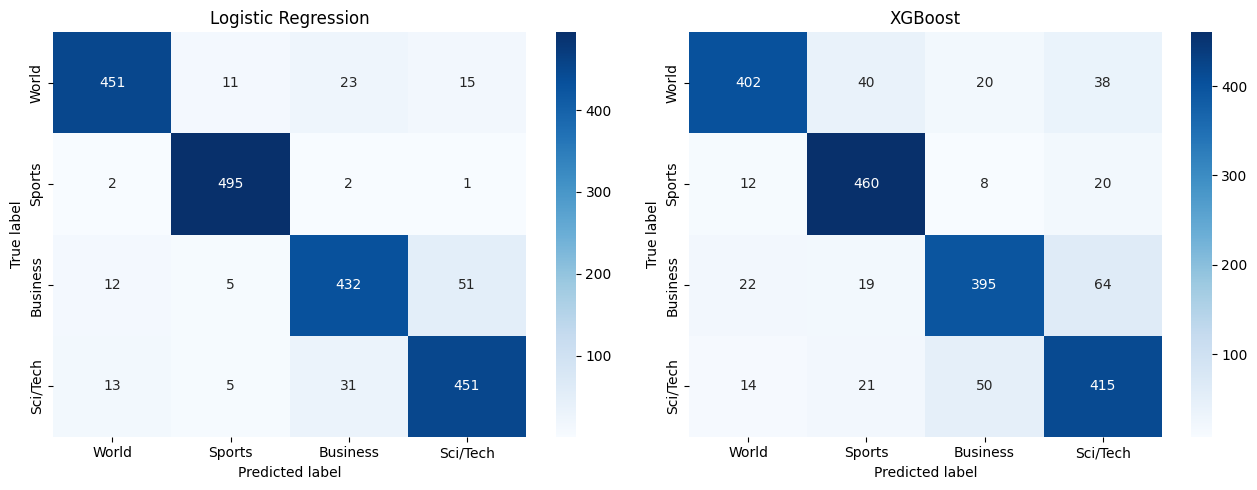

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=range(len(label_names)))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()